In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

import numpy as np

import polars as pl
pl.Config.set_tbl_rows(20)

import seaborn as sns

from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [3]:
# wt-dko comparison
path_correlations_wt = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_dko_downsampled_mito/gene_correlations_wt/ranked_correlations.csv'
path_correlations_dko = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_dko_downsampled_mito/gene_correlations_dko/ranked_correlations.csv'

In [4]:
# wt-tko comparison
path_correlations_wt = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_dko_downsampled_mito/gene_correlations_wt/ranked_correlations.csv'
path_correlations_tko = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_tko_downsampled_mito/gene_correlations_tko/ranked_correlations.csv'

In [5]:
df_wt = pl.read_csv(path_correlations_wt)
df_tko = pl.read_csv(path_correlations_tko)

In [6]:
# wt-tko comparison
df_wt = df_wt.rename({"correlation": "correlation_wt"})
df_tko = df_tko.rename({"correlation": "correlation_tko"})

df_wt = df_wt.with_columns(
    pl.col("correlation_wt").abs().alias("correlation_abs_wt")
)

df_tko = df_tko.with_columns(
    pl.col("correlation_tko").abs().alias("correlation_abs_tko")
)

df_combined = df_wt.join(df_tko, on=['gene_1', 'gene_2'])

df_combined = df_combined.with_columns(
    (pl.col("correlation_abs_tko") - pl.col("correlation_abs_wt")).alias('correlation_tko-correlation_wt')
)

print(df_combined)

shape: (156_866_328, 7)
┌────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ gene_1     ┆ gene_2       ┆ correlation_ ┆ correlation ┆ correlation ┆ correlation ┆ correlation │
│ ---        ┆ ---          ┆ wt           ┆ _abs_wt     ┆ _tko        ┆ _abs_tko    ┆ _tko-correl │
│ str        ┆ str          ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ation_wt    │
│            ┆              ┆ f64          ┆ f64         ┆ f64         ┆ f64         ┆ ---         │
│            ┆              ┆              ┆             ┆             ┆             ┆ f64         │
╞════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ WASH7P     ┆ AL627309.1   ┆ 0.041024     ┆ 0.041024    ┆ 0.057126    ┆ 0.057126    ┆ 0.016102    │
│ WASH7P     ┆ RP11-34P13.1 ┆ -0.00224     ┆ 0.00224     ┆ 0.021874    ┆ 0.021874    ┆ 0.019634    │
│            ┆ 3            ┆              ┆             ┆         

In [7]:
prefixes = ["RPL", "RPS", "HIST", "MT-", "RNA"]

# Create a mask for each condition and combine with OR
filter_mask = (
    ~(
        df_combined["gene_1"].str.starts_with(prefixes[0]) |
        df_combined["gene_1"].str.starts_with(prefixes[1]) |
        df_combined["gene_1"].str.starts_with(prefixes[2]) |
        df_combined["gene_1"].str.starts_with(prefixes[3]) |
        df_combined["gene_1"].str.starts_with(prefixes[4]) |
        df_combined["gene_2"].str.starts_with(prefixes[0]) |
        df_combined["gene_2"].str.starts_with(prefixes[1]) |
        df_combined["gene_2"].str.starts_with(prefixes[2]) |
        df_combined["gene_2"].str.starts_with(prefixes[3]) |
        df_combined["gene_2"].str.starts_with(prefixes[4])
    )
)

# Filter the DataFrame
df_combined = df_combined.filter(filter_mask)


rho_lim = 0.4
df_filtered = df_combined.filter(
    (pl.col("correlation_abs_tko") > rho_lim) | (pl.col("correlation_abs_wt") > rho_lim)
)


In [15]:
path_zero_ratio_tko = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/tko_zero_ratio_cutoffs.bed'

df_gene_expr = pd.read_csv(path_zero_ratio_tko, sep='\t')

print(list(df_gene_expr.columns))

df_bivalent = df_gene_expr.loc[df_gene_expr['Promoter Class'] == 'Bivalent']

bivalent_genes = list(df_bivalent['gene'])

['#chrom', 'start', 'stop', 'length', 'strand', 'gene', 'Ratio Bivalent', 'Ratio H3K27me3', 'Ratio H3K4me3', 'MeanOverall_dko', 'Mean1_dko', 'Mean2_dko', 'MeanFC_dko', 'MeanLog2FC_dko', 'ProbDiffMean_dko', 'ResultDiffMean_dko', 'DispOverall_dko', 'Disp1_dko', 'Disp2_dko', 'DispFC_dko', 'DispLog2FC_dko', 'ProbDiffDisp_dko', 'ResultDiffDisp_dko', 'MeanOverall_tko', 'Mean1_tko', 'Mean2_tko', 'MeanFC_tko', 'MeanLog2FC_tko', 'ProbDiffMean_tko', 'ResultDiffMean_tko', 'DispOverall_tko', 'Disp1_tko', 'Disp2_tko', 'DispFC_tko', 'DispLog2FC_tko', 'ProbDiffDisp_tko', 'ResultDiffDisp_tko', 'Promoter Class', 'mean_wt', 'var_wt', 'std_wt', 'dispersion_nonzero_wt', 'coeff_var_nonzero_wt', 'dispersion_wt', 'coeff_var_wt', 'log_mean_wt', 'log_var_wt', 'log_std_wt', 'log_dispersion_nonzero_wt', 'log_coeff_var_nonzero_wt', 'log_dispersion_wt', 'log_coeff_var_wt', 'zero_ratio_wt', 'nonzero_ratio_wt', 'mean_tko', 'var_tko', 'std_tko', 'dispersion_nonzero_tko', 'coeff_var_nonzero_tko', 'dispersion_tko', 'co

In [9]:
# here we want to get the number of genes that are bivalent in either column
# we can then compare to the larger list or low correlation genes

print(df_combined.height)

df_bivalent_1 = df_combined.filter(
    pl.col("gene_1").is_in(bivalent_genes)
)
print(df_bivalent_1.height / df_combined.height)

df_bivalent_2 = df_combined.filter(
    pl.col("gene_2").is_in(bivalent_genes)
)
print(df_bivalent_2.height / df_combined.height)

print(df_filtered.height)

df_bivalent_1 = df_filtered.filter(
    pl.col("gene_1").is_in(bivalent_genes)
)

print(df_bivalent_1.height / df_filtered.height)

df_bivalent_2 = df_filtered.filter(
    pl.col("gene_2").is_in(bivalent_genes)
)

print(df_bivalent_2.height / df_filtered.height)


150467878
0.16405135985236663
0.1552938096196186
26174
0.21318866050278903
0.2259876213035837


In [16]:
df_bivalent = df_filtered.filter(
    pl.col("gene_1").is_in(bivalent_genes) | pl.col("gene_2").is_in(bivalent_genes)
)

print(df_bivalent)



shape: (10_142, 7)
┌─────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────────────┐
│ gene_1  ┆ gene_2       ┆ correlation_ ┆ correlation_ ┆ correlation_ ┆ correlation_ ┆ correlation │
│ ---     ┆ ---          ┆ wt           ┆ abs_wt       ┆ tko          ┆ abs_tko      ┆ _tko-correl │
│ str     ┆ str          ┆ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ation_wt    │
│         ┆              ┆ f64          ┆ f64          ┆ f64          ┆ f64          ┆ ---         │
│         ┆              ┆              ┆              ┆              ┆              ┆ f64         │
╞═════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═════════════╡
│ RBP7    ┆ TDGF1        ┆ 0.061142     ┆ 0.061142     ┆ 0.412511     ┆ 0.412511     ┆ 0.351369    │
│ RBP7    ┆ ESRG         ┆ 0.091895     ┆ 0.091895     ┆ 0.410659     ┆ 0.410659     ┆ 0.318764    │
│ RBP7    ┆ RP11-1144P22 ┆ 0.058857     ┆ 0.058857     ┆ 0.405922     ┆ 

In [17]:
# get genes most central to network

# Combine both gene columns into a single column
all_genes = df_bivalent.select(["gene_1", "gene_2"]).melt().select("value")

# Count, sort, limit
top_genes = (
    all_genes
    .group_by("value")
    .count()
    .rename({"value": "gene", "count": "count"})
    .sort("count", descending=True)
    .limit(200)
    .to_dicts()
)

print(top_genes)

[{'gene': 'ESRP1', 'count': 408}, {'gene': 'AK4', 'count': 383}, {'gene': 'GAL', 'count': 375}, {'gene': 'MAL2', 'count': 348}, {'gene': 'PYCARD', 'count': 345}, {'gene': 'RARRES2', 'count': 314}, {'gene': 'FLT1', 'count': 279}, {'gene': 'NODAL', 'count': 243}, {'gene': 'CDH3', 'count': 238}, {'gene': 'PPP1R14A', 'count': 224}, {'gene': 'NPW', 'count': 217}, {'gene': 'TUBA4A', 'count': 212}, {'gene': 'PRTG', 'count': 201}, {'gene': 'OSBPL10', 'count': 193}, {'gene': 'SLC7A5', 'count': 187}, {'gene': 'UTF1', 'count': 183}, {'gene': 'MARCKS', 'count': 180}, {'gene': 'HTATIP2', 'count': 171}, {'gene': 'TDRP', 'count': 167}, {'gene': 'PRDM14', 'count': 165}, {'gene': 'PDGFA', 'count': 162}, {'gene': 'COBL', 'count': 155}, {'gene': 'SIGIRR', 'count': 145}, {'gene': 'HEY2', 'count': 140}, {'gene': 'TDGF1', 'count': 138}, {'gene': 'CXCL12', 'count': 136}, {'gene': 'RP11-1144P22.1', 'count': 131}, {'gene': 'ACTC1', 'count': 131}, {'gene': 'C4orf48', 'count': 126}, {'gene': 'CDH1', 'count': 125

/tmp/ipykernel_319180/3443121034.py:4: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  all_genes = df_bivalent.select(["gene_1", "gene_2"]).melt().select("value")
/tmp/ipykernel_319180/3443121034.py:10: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  .count()


25484
26174
0.9736379613356766


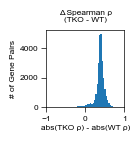

In [19]:
# plot
fig, ax = plt.subplots()
fig.set_size_inches(1, 1)

df_plot = df_filtered

plt.hist(df_plot['correlation_tko-correlation_wt'], bins=40)
ax.set_xlim([-1,1])
ax.set_xlabel('abs(TKO ρ) - abs(WT ρ)')
ax.set_ylabel('# of Gene Pairs')
plt.title('Δ Spearman ρ\n(TKO - WT)')

df_corr_plus = df_plot.filter(
    (pl.col("correlation_tko-correlation_wt") > 0)
)

print(df_corr_plus.shape[0])
print(df_plot.shape[0])

ratio = df_corr_plus.shape[0] / df_plot.shape[0]

print(ratio)

path_out = f'figures/tko_wt_correlation_{rho_lim}.svg'
plt.savefig(path_out)

In [6]:
df_wt = pl.read_csv(path_correlations_wt)
df_dko = pl.read_csv(path_correlations_dko)

In [ ]:
df_wt = df_wt.rename({"correlation": "correlation_wt"})
df_dko = df_dko.rename({"correlation": "correlation_dko"})

df_wt = df_wt.with_columns(
    pl.col("correlation_wt").abs().alias("correlation_abs_wt")
)

df_dko = df_dko.with_columns(
    pl.col("correlation_dko").abs().alias("correlation_abs_dko")
)

df_combined = df_wt.join(df_dko, on=['gene_1', 'gene_2'])

df_combined = df_combined.with_columns(
    (pl.col("correlation_abs_dko") - pl.col("correlation_abs_wt")).alias('correlation_dko-correlation_wt')
)

print(df_combined)

In [ ]:
rho_lim = 0.4
df_filtered = df_combined.filter(
    (pl.col("correlation_abs_dko") > rho_lim) | (pl.col("correlation_abs_wt") > rho_lim)
)

prefixes = ["RPL", "RPS", "HIST", "MT-", "RNA"]

# Create a mask for each condition and combine with OR
filter_mask = (
    ~(
        df_filtered["gene_1"].str.starts_with(prefixes[0]) |
        df_filtered["gene_1"].str.starts_with(prefixes[1]) |
        df_filtered["gene_1"].str.starts_with(prefixes[2]) |
        df_filtered["gene_1"].str.starts_with(prefixes[3]) |
        df_filtered["gene_1"].str.starts_with(prefixes[4]) |
        df_filtered["gene_2"].str.starts_with(prefixes[0]) |
        df_filtered["gene_2"].str.starts_with(prefixes[1]) |
        df_filtered["gene_2"].str.starts_with(prefixes[2]) |
        df_filtered["gene_2"].str.starts_with(prefixes[3]) |
        df_filtered["gene_2"].str.starts_with(prefixes[4])
    )
)

# Filter the DataFrame
df_filtered = df_filtered.filter(filter_mask)

df_corr_plus = df_filtered.filter(
    (pl.col("correlation_dko-correlation_wt") > 0)
)

print(df_corr_plus)
print(df_filtered)

ratio = df_corr_plus.shape[0] / df_filtered.shape[0]

print(ratio)

In [ ]:
# plot
fig, ax = plt.subplots()
fig.set_size_inches(1, 1)

x = df_filtered['correlation_dko-correlation_wt'].to_numpy()

ax.hist(x, bins=40)
ax.set_xlim([-1,1])
ax.set_xlabel('abs(DKO ρ) - abs(WT ρ)')
ax.set_ylabel('# of Gene Pairs')
plt.title('Δ Spearman ρ\n(DKO - WT)')

path_out = f'figures/dko_wt_correlation_{rho_lim}.svg'
plt.savefig(path_out)

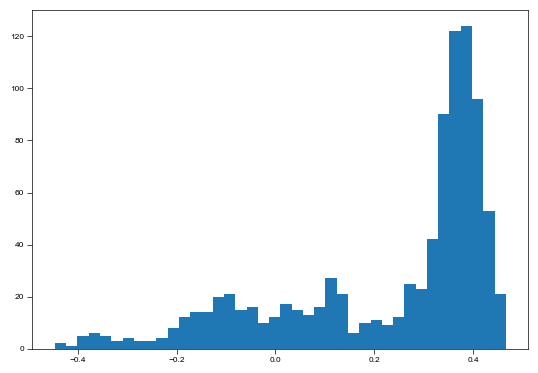

In [12]:
# compute some average increase in correlation for each gene
# this is done separately for DKO and TKO

all_genes = list(set(df_filtered['gene_1']) | set(df_filtered['gene_2']))
correlation_holder = {gene:[] for gene in all_genes}

for record in df_filtered.iter_rows(named=True):
    
    correlation_holder[record['gene_1']].append(record[f'correlation_tko-correlation_wt'])
    correlation_holder[record['gene_2']].append(record[f'correlation_tko-correlation_wt'])

mean_corr_records = []
for gene in correlation_holder:
    mean_corr_records.append({'gene': gene, 'mean_correlation_difference': np.mean(correlation_holder[gene])})

df_mean_corrs = pd.DataFrame(mean_corr_records)

plt.hist(df_mean_corrs['mean_correlation_difference'], bins=40)
plt.show()

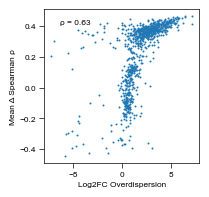

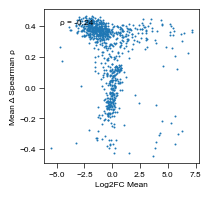

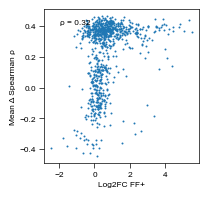

/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


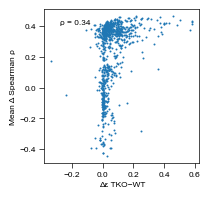

In [35]:
def corrfunc(x, y, **kws):
    # Convert to numpy arrays
    x = np.asarray(x)
    y = np.asarray(y)
    
    # Mask out NaN or inf values
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    ax = plt.gca()
    if len(x) > 1:  # Need at least 2 points for correlation
        r, p = pearsonr(x, y)
        ax.annotate(f"ρ = {r:.2f}", xy=(.1, .9), xycoords=ax.transAxes)
    else:
        ax.annotate("ρ = NaN\np = NaN", xy=(.1, .9), xycoords=ax.transAxes)

df_merge = df_gene_expr.merge(df_mean_corrs, left_on='gene', right_on='gene')
#df_merge = df_merge.loc[(df_merge['log_mean_wt'] > -6) | (df_merge['log_mean_wt'] > -6)]

#df_merge = df_merge.loc[(df_merge['mean_correlation_difference'] > 0.2)]

figsize=(2,2)

fig, ax = plt.subplots(figsize=figsize)
sns.scatterplot(data=df_merge, x='DispLog2FC_tko', y='mean_correlation_difference', s=2, linewidth=0)
corrfunc(df_merge['DispLog2FC_tko'], df_merge['mean_correlation_difference'])
plt.ylabel('Mean Δ Spearman ρ')
plt.xlabel('Log2FC Overdispersion')
fig.savefig('figures/log2fcdisp_vs_corrdiff.svg')
plt.show()

fig, ax = plt.subplots(figsize=figsize)
sns.scatterplot(data=df_merge, x='MeanLog2FC_tko', y='mean_correlation_difference', s=2, linewidth=0)
corrfunc(df_merge['MeanLog2FC_tko'], df_merge['mean_correlation_difference'])
plt.ylabel('Mean Δ Spearman ρ')
plt.xlabel('Log2FC Mean')
fig.savefig('figures/log2fcmean_vs_corrdiff.svg')
plt.show()

fig, ax = plt.subplots(figsize=figsize)
sns.scatterplot(data=df_merge, x='log_dispersion_nonzero_diff_tko', y='mean_correlation_difference', s=2, linewidth=0)
corrfunc(df_merge['log_dispersion_nonzero_diff_tko'], df_merge['mean_correlation_difference'])
plt.ylabel('Mean Δ Spearman ρ')
plt.xlabel('Log2FC FF+')
fig.savefig('figures/nonzerodisp_vs_corrdiff.svg')
plt.show()

df_merge['log_residual_diff_tko'] = np.log(df_merge['residual_diff_tko'])

# let's look to see if genes are

fig, ax = plt.subplots(figsize=figsize)
sns.scatterplot(data=df_merge, x='residual_diff_tko', y='mean_correlation_difference', s=2, linewidth=0)
corrfunc(df_merge['residual_diff_tko'], df_merge['mean_correlation_difference'])
plt.ylabel('Mean Δ Spearman ρ')
plt.xlabel('Δε TKO−WT')
fig.savefig('figures/deltaepsilon_vs_corrdiff.svg')
plt.show()

In [ ]:
corr_diff_dko = [1 if corr > 0 else 0 for corr in list(df_combined_filt['correlation_dko-correlation_wt'])]
print('percent of genes with increases in correlation in DKO:', sum(corr_diff_dko)/len(corr_diff_dko))

In [ ]:
corr_diff_tko = [1 if corr > 0 else 0 for corr in list(df_combined_filt['correlation_tko-correlation_wt'])]
print('percent of genes with increases in correlation in TKO:', sum(corr_diff_tko)/len(corr_diff_tko))

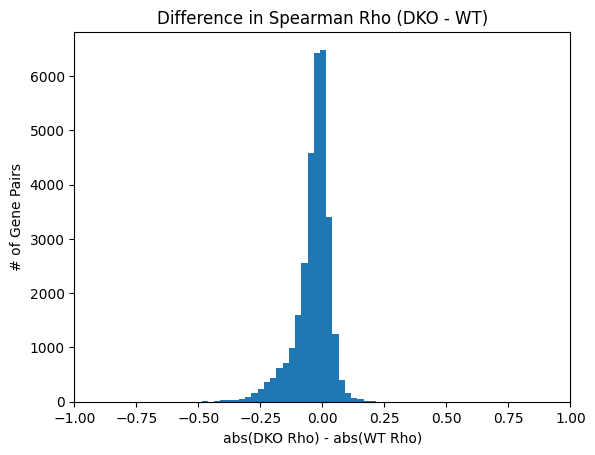

In [13]:
plt.hist(df_combined_filt['correlation_dko-correlation_wt'], bins=40)
plt.xlim([-1,1])
plt.xlabel('abs(DKO Rho) - abs(WT Rho)')
plt.ylabel('# of Gene Pairs')
plt.title('Difference in Spearman Rho (DKO - WT)')
plt.show()

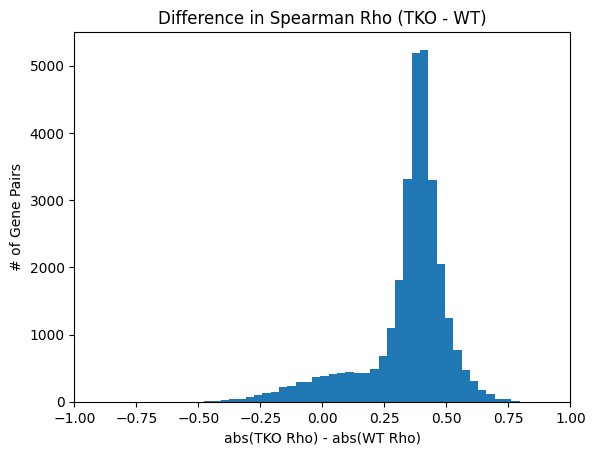

In [14]:
plt.hist(df_combined_filt['correlation_tko-correlation_wt'], bins=40)
plt.xlim([-1,1])
plt.xlabel('abs(TKO Rho) - abs(WT Rho)')
plt.ylabel('# of Gene Pairs')
plt.title('Difference in Spearman Rho (TKO - WT)')
plt.show()